# BİL462 - Ödev 1: Personality Type Prediction

Bu notebook, `personality_dataset.csv` veri seti ile kişilik tipini (`Personality`) tahmin etmek için hazırlanmıştır.

Yönergeye uygun olarak:
- Problem tanımı
- Keşifsel veri analizi (EDA)
- Veri ön işleme
- Train/Test bölme (%80/%20)
- En az iki model kurulumu
- Model değerlendirme (Accuracy, Precision, Recall, F1, Confusion Matrix, ROC)
- 5-Fold Cross Validation
- Hiperparametre optimizasyonu (Grid Search)
- Sonuç yorumları

adımları uygulanmıştır.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Veri setini oku
df = pd.read_csv("personality_dataset.csv")

print("=== Problem Tanımı ===")
print("Veri seti hangi problem için oluşturulmuştur?: Kişilik tipi (Introvert/Extrovert) tahmini")
print(f"Gözlem sayısı: {df.shape[0]}")
print(f"Özellik sayısı (hedef hariç): {df.shape[1]-1}")
print("Hedef değişken: Personality")
print("Problem türü: Sınıflandırma")

=== Problem Tanımı ===
Veri seti hangi problem için oluşturulmuştur?: Kişilik tipi (Introvert/Extrovert) tahmini
Gözlem sayısı: 2900
Özellik sayısı (hedef hariç): 7
Hedef değişken: Personality
Problem türü: Sınıflandırma



=== EDA ===

İlk 5 satır:


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert



Veri tipleri:
Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object

Eksik veri sayıları:
Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

Temel istatistikler:


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,2837.000000,2827,2838.000000,2834.000000,2848,2823.000000,2835.000000,2900
unique,NaN,2,NaN,NaN,2,NaN,NaN,2
top,NaN,No,NaN,NaN,No,NaN,NaN,Extrovert
freq,NaN,1417,NaN,NaN,1441,NaN,NaN,1491
mean,4.505816,NaN,3.963354,3.000000,NaN,6.268863,3.564727,NaN
std,3.479192,NaN,2.903827,2.247327,NaN,4.289693,2.926582,NaN
min,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN
25%,2.000000,NaN,2.000000,1.000000,NaN,3.000000,1.000000,NaN
50%,4.000000,NaN,3.000000,3.000000,NaN,5.000000,3.000000,NaN
75%,8.000000,NaN,6.000000,5.000000,NaN,10.000000,6.000000,NaN


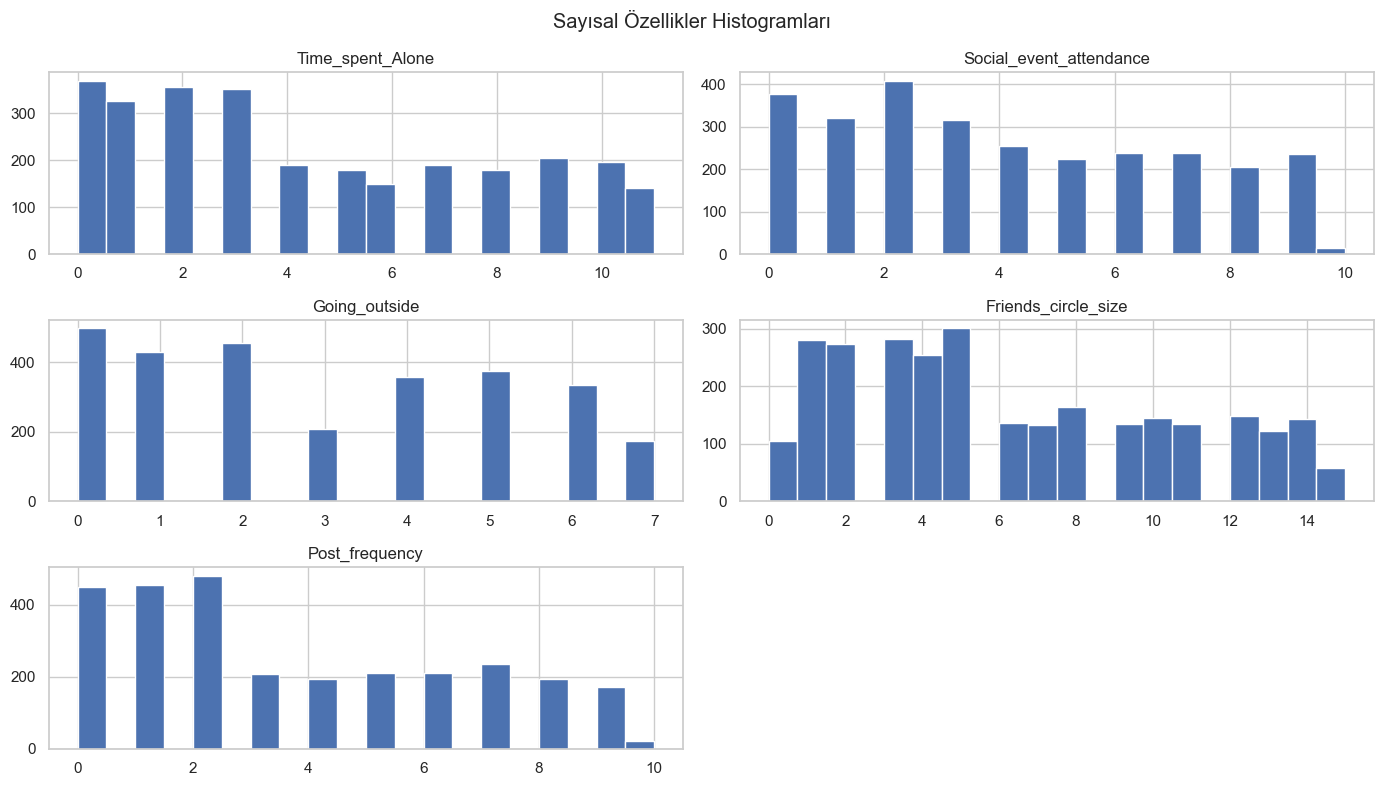

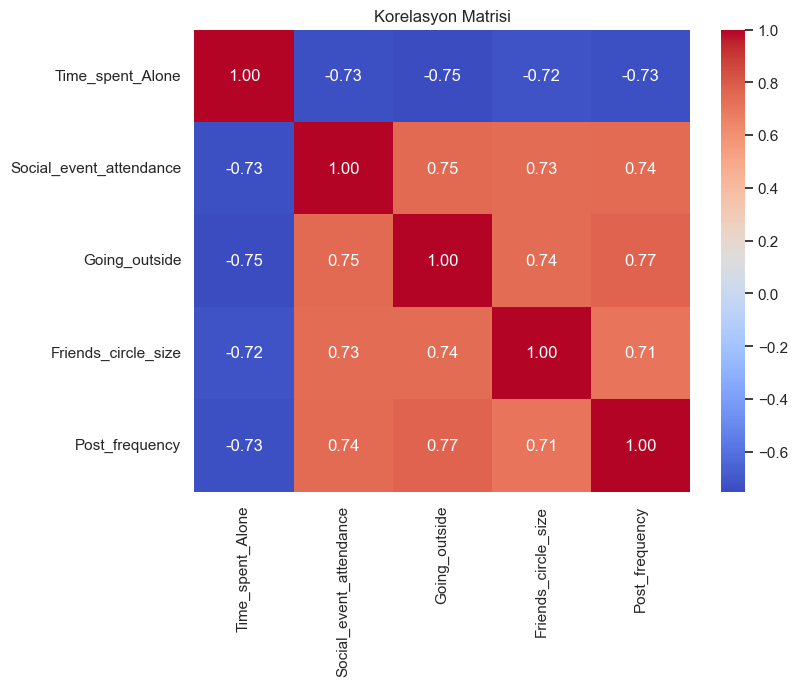

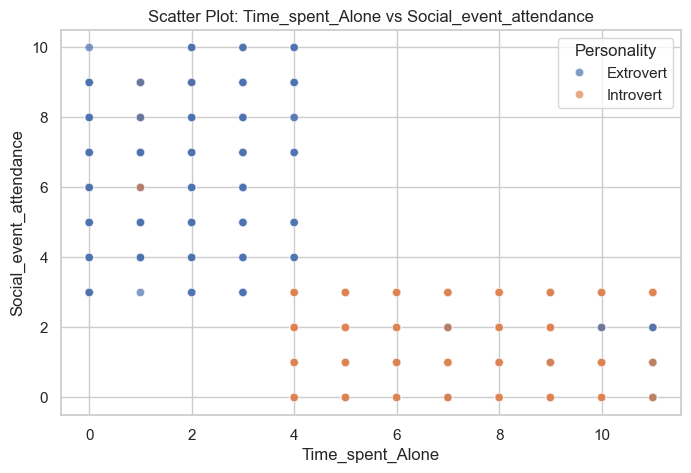

In [2]:
print("\n=== EDA ===")
print("\nİlk 5 satır:")
display(df.head())

print("\nVeri tipleri:")
print(df.dtypes)

print("\nEksik veri sayıları:")
print(df.isnull().sum())

print("\nTemel istatistikler:")
display(df.describe(include="all"))

# Sayısal sütunlar için histogram
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if "Personality" in numeric_cols:
    numeric_cols.remove("Personality")

df[numeric_cols].hist(bins=20, figsize=(14, 8))
plt.suptitle("Sayısal Özellikler Histogramları")
plt.tight_layout()
plt.show()

# Korelasyon matrisi (sayısal sütunlar)
corr = df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi")
plt.show()

# Scatter plot örneği
if len(numeric_cols) >= 2:
    sns.scatterplot(data=df, x=numeric_cols[0], y=numeric_cols[1], hue="Personality", alpha=0.7)
    plt.title(f"Scatter Plot: {numeric_cols[0]} vs {numeric_cols[1]}")
    plt.show()

Train set boyutu: (2320, 7)
Test set boyutu: (580, 7)

=== Logistic Regression ===
              precision    recall  f1-score   support

   Extrovert       0.93      0.90      0.91       298
   Introvert       0.89      0.93      0.91       282

    accuracy                           0.91       580
   macro avg       0.91      0.91      0.91       580
weighted avg       0.91      0.91      0.91       580

Confusion Matrix:
[[267  31]
 [ 21 261]]

=== KNN ===
              precision    recall  f1-score   support

   Extrovert       0.94      0.89      0.92       298
   Introvert       0.89      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580

Confusion Matrix:
[[266  32]
 [ 17 265]]

=== Decision Tree ===
              precision    recall  f1-score   support

   Extrovert       0.94      0.89      0.91       298
   Introvert       0.89      0.94   

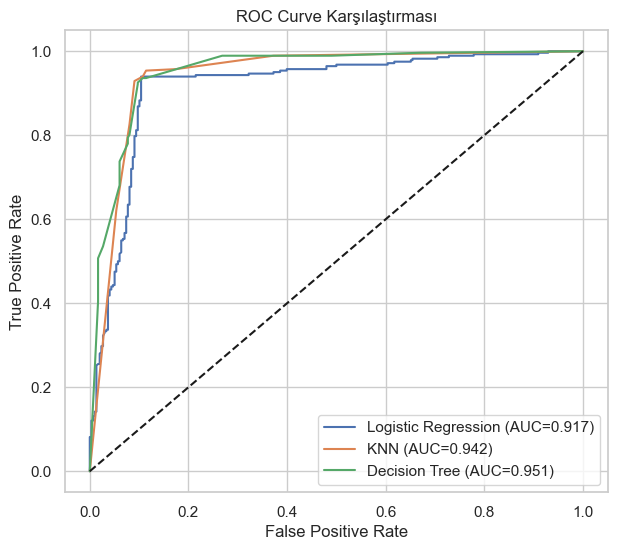


Model Karşılaştırma Tablosu:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,KNN,0.915517,0.892256,0.939716,0.915371,0.941573
2,Decision Tree,0.913793,0.891892,0.936170,0.913495,0.950509
0,Logistic Regression,0.910345,0.893836,0.925532,0.909408,0.917065


In [3]:
# Özellik ve hedef ayrımı
X = df.drop(columns=["Personality"])
y = df["Personality"]

# Hedefi sayısallaştır (ROC-AUC için)
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Introvert/Extrovert -> 0/1

# Kategorik ve sayısal sütunları ayır
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Ön işleme
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# Train/Test bölme (%80/%20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

print("Train set boyutu:", X_train.shape)
print("Test set boyutu:", X_test.shape)

# En az 2 model (3 model kullanıyoruz)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6),
}

results = []
plt.figure(figsize=(7, 6))

for name, model in models.items():
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # ROC için olasılık veya decision_function
    if hasattr(clf.named_steps["model"], "predict_proba"):
        y_score = clf.predict_proba(X_test)[:, 1]
    else:
        y_score = clf.decision_function(X_test)

    auc = roc_auc_score(y_test, y_score)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc,
    })

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("Confusion Matrix:")
    print(cm)

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Karşılaştırması")
plt.legend()
plt.show()

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
print("\nModel Karşılaştırma Tablosu:")
display(results_df)

In [4]:
# 5-Fold Cross Validation (en az 1 model için)
cv_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

cv_scores = cross_val_score(cv_model, X, y_encoded, cv=5, scoring="f1")
print("5-Fold CV F1 skorları:", cv_scores)
print("Ortalama CV F1:", cv_scores.mean())

# Hiperparametre optimizasyonu (Grid Search)
grid_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier()),
    ]
)

param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["minkowski", "manhattan"],
}

grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=1,
)

grid_search.fit(X_train, y_train)

print("\nEn iyi hiperparametreler:", grid_search.best_params_)
print("En iyi CV F1 skoru:", grid_search.best_score_)

best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)

print("\nGridSearch sonrası test performansı:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best))

5-Fold CV F1 skorları: [0.96625222 0.9314587  0.91901408 0.91319444 0.90357143]
Ortalama CV F1: 0.9266981754488685

En iyi hiperparametreler: {'model__metric': 'minkowski', 'model__n_neighbors': 11, 'model__weights': 'uniform'}
En iyi CV F1 skoru: 0.9374867665924576

GridSearch sonrası test performansı:
Accuracy: 0.9155172413793103
Precision: 0.8922558922558923
Recall: 0.9397163120567376
F1: 0.9153713298791019


## Sonuçların Yorumlanması

Bu bölümde aşağıdaki sorular kod çıktısına göre doldurulmalıdır:

1. Hangi model daha iyi performans göstermiştir?
   - `results_df` tablosundaki Accuracy/F1/ROC_AUC değerlerine göre yorumlayın.

2. Model overfitting yapıyor mu?
   - Eğitim ve test skorları arasında büyük fark varsa overfitting ihtimali vardır.
   - Özellikle Decision Tree modelinde bu risk daha yüksektir.

3. Veri setinin büyüklüğü model performansını nasıl etkileyebilir?
   - Daha büyük veri seti, genellenebilirliği artırabilir ve modelin daha dengeli öğrenmesini sağlayabilir.

4. Daha iyi sonuç almak için ne yapılabilir?
   - Daha fazla özellik mühendisliği
   - Dengesiz sınıf varsa dengeleme
   - Farklı modeller (SVM, Random Forest, XGBoost vb.)
   - Daha kapsamlı hiperparametre araması
   - Outlier analizi ve gelişmiş ön işleme